In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("dataset.csv")
df.columns = df.columns.str.strip()  # fix hidden spaces

print(df.head())
print(df.info())

   Marital status  Application mode  Application order  Course  \
0               1                 8                  5       2   
1               1                 6                  1      11   
2               1                 1                  5       5   
3               1                 8                  2      15   
4               2                12                  1       3   

   Daytime/evening attendance  Previous qualification  Nacionality  \
0                           1                       1            1   
1                           1                       1            1   
2                           1                       1            1   
3                           1                       1            1   
4                           0                       1            1   

   Mother's qualification  Father's qualification  Mother's occupation  ...  \
0                      13                      10                    6  ...   
1                       

In [ ]:
df['Target'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)
df = df.dropna()

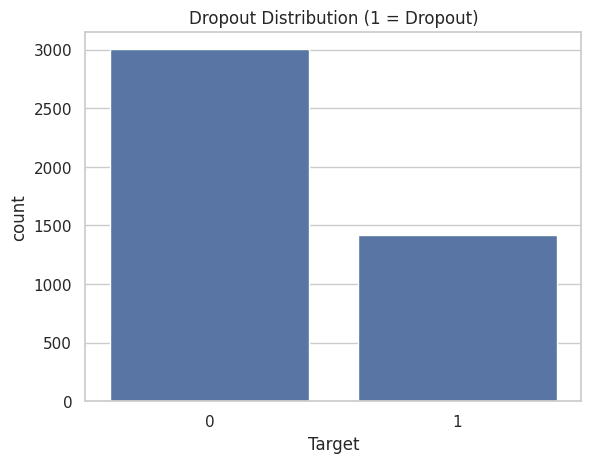

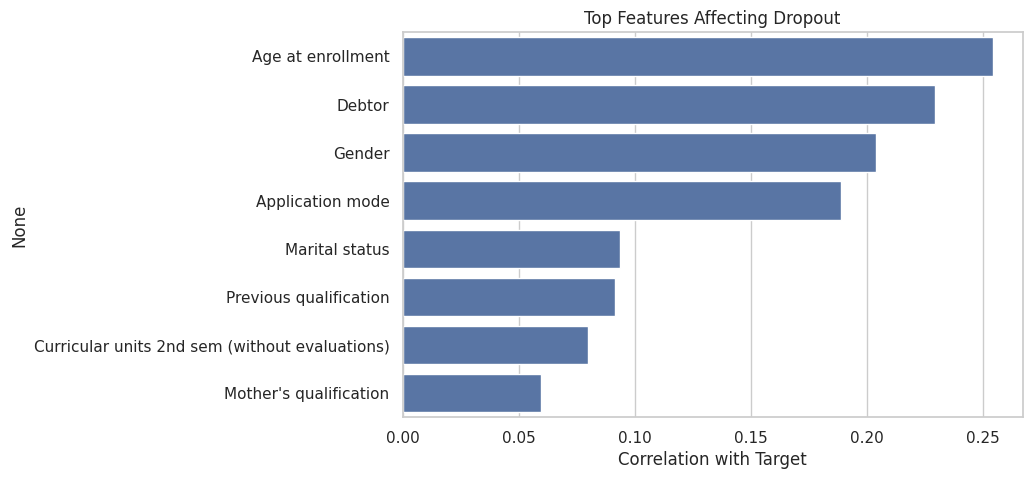

In [ ]:
# Target distribution
plt.figure()
sns.countplot(x='Target', data=df)
plt.title("Dropout Distribution (1 = Dropout)")
plt.show()

# Simplified correlation bar chart
corr = df.select_dtypes(include=['number']).corr()['Target'].sort_values(ascending=False)
top_features = corr.index[1:9]
plt.figure(figsize=(8,5))
sns.barplot(x=corr[top_features], y=top_features)
plt.title("Top Features Affecting Dropout")
plt.xlabel("Correlation with Target")
plt.show()

In [ ]:
X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


 Logistic Regression
Accuracy: 0.8610169491525423
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       569
           1       0.79      0.83      0.81       316

    accuracy                           0.86       885
   macro avg       0.85      0.85      0.85       885
weighted avg       0.86      0.86      0.86       885



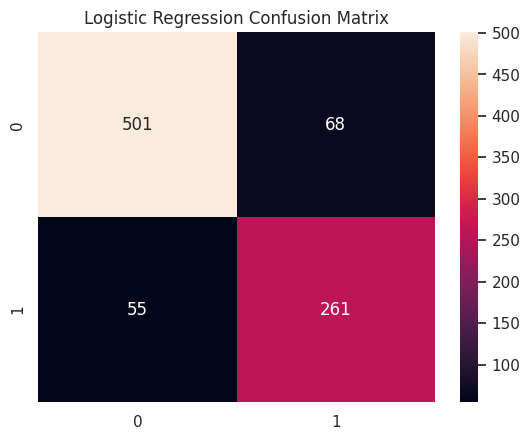

In [ ]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("\n Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()


 SVM
Accuracy: 0.8677966101694915
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       569
           1       0.82      0.80      0.81       316

    accuracy                           0.87       885
   macro avg       0.86      0.85      0.86       885
weighted avg       0.87      0.87      0.87       885



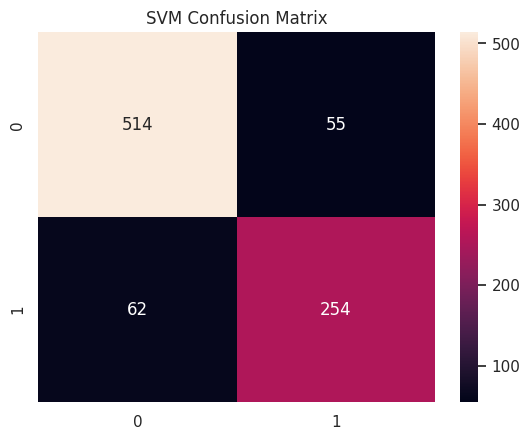

In [ ]:
svm_model = SVC(probability=True, class_weight='balanced')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("\n SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.show()

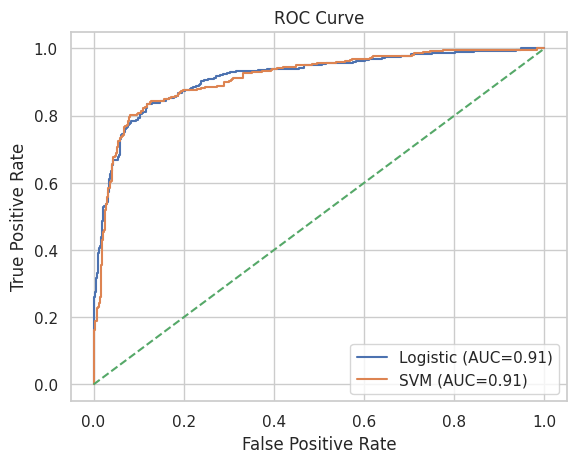

In [ ]:
y_prob_log = log_model.predict_proba(X_test)[:,1]
y_prob_svm = svm_model.predict_proba(X_test)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

auc_log = auc(fpr_log, tpr_log)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={auc_log:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

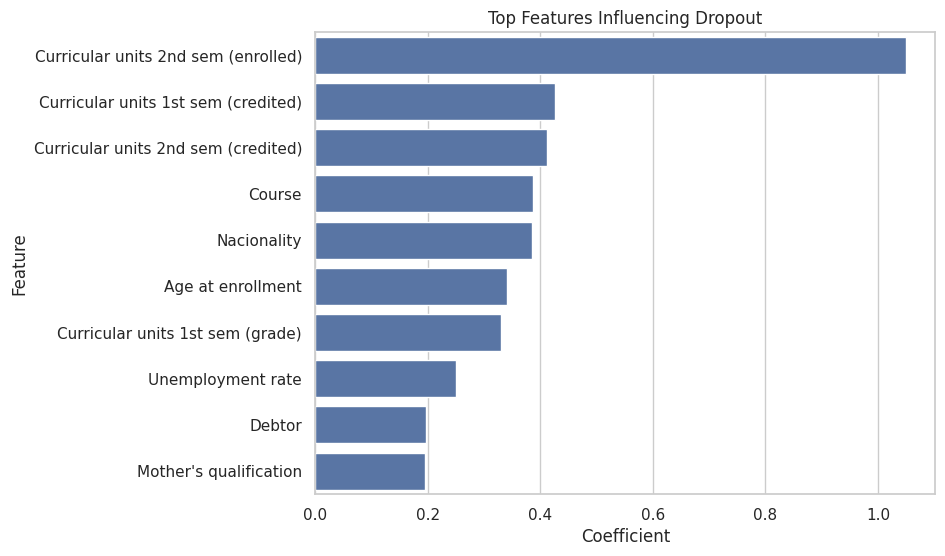


Top Features:
                                 Feature  Coefficient
26  Curricular units 2nd sem (enrolled)     1.049489
19  Curricular units 1st sem (credited)     0.425495
25  Curricular units 2nd sem (credited)     0.412353
3                                Course     0.386511
6                           Nacionality     0.385765
17                    Age at enrollment     0.340182
23     Curricular units 1st sem (grade)     0.329905
31                    Unemployment rate     0.249701
13                               Debtor     0.196712
7                Mother's qualification     0.195287

Project Completed Successfully
Logistic AUC: 0.9148572890480746
SVM AUC: 0.9129162866232119


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Coefficient", y="Feature", data=coefficients.head(10))
plt.title("Top Features Influencing Dropout")
plt.show()

print("\nTop Features:\n", coefficients.head(10))
print("\nProject Completed Successfully")
print("Logistic AUC:", auc_log)
print("SVM AUC:", auc_svm)

In [ ]:
df.shape

(4424, 35)